# Do-Calculus for Causal Diagram 7.5 from "The Book of Why" (napkin problem)



In "The Book of Why" the below causal diagram is described as the "simplest model" where estimation of the causal effect goes beyond front and back-door adjustment and thus requires do-calculus.

<figure>
<img src="images/Figure-7.5-Napkin-with-W.png" alt="Napkin" width="25%">

<figcaption>Napkin</figcaption>
</figure>

The qualitative knowledge of causal relationships in the domain is represented by a causal model shown in Figure 1.

<figure>
<img src="images/figure1.png" alt="figure1" width="25%">
<figcaption>figure1</figcaption>
</figure>

The treatment variable is $X$ and the outcome variable is $Y$.
We show that the causal effect $do(X = x)$ on $Y$, written as $P_{X}\left(Y\right)$, is identifiable from a distribution over the observed variables $P\left(W,X,Y,Z\right)$.


## Derivation

**Theorem.** *The causal effect of $X$ on $Y$ is identifiable from $P_{}\left(W,X,Y,Z\right)$ and is given by the formula*

$$
P_{X}\left(Y\right) = \frac{\sum_{W}{P\left(X,Y \mid W,Z\right)P\left(W\right)}}{\sum_{W}{P\left(X \mid W,Z\right)P\left(W\right)}}
$$

**Proof.**

$$
\begin{aligned}
& P_{X}\left(Y\right) && \text{(1)} \\
&= P_{W,X,Z}\left(Y\right) && \text{(2)} \\
&= P_{W,Z}\left(Y \mid X\right) && \text{(3)} \\
&= \frac{P_{W,Z}\left(X,Y\right)}{P_{W,Z}\left(X\right)} && \text{(4)}
\end{aligned}
$$

<figure>
<img src="images/figure2.png" alt="figure2" width="25%">
<figcaption>figure2</figcaption>
<figure>
<img src="images/figure3.png" alt="figure3" width="25%">
<figcaption>figure3</figcaption>
</figure>

Eq. (4) follows from the definition of conditional probability.
**Task 1: Compute $P_{W,Z}\left(X,Y\right)$**
We compute the numerator.

$$
\begin{aligned}
& P_{W,Z}\left(X,Y\right) && \text{(5)} \\
&= P_{Z}\left(X,Y\right) && \text{(6)} \\
&= \sum_{W}{P_{Z}\left(W,X,Y\right)} && \text{(7)}
\end{aligned}$$

<figure>
<img src="images/figure4.png" alt="figure4" width="25%">
<figcaption>figure4</figcaption>
</figure>

Eq. (7) follows from summing over $W$.
**Task 1.1: Compute $P_{Z}\left(W,X,Y\right)$**

We compute the effect inside the sum.

$$
\begin{aligned}
& P_{Z}\left(W,X,Y\right) && \text{(8)} \\
&= P_{Z}\left(X,Y \mid W\right)P_{Z}\left(W\right) && \text{(9)} \\
&= P_{Z}\left(X,Y \mid W\right)P_{}\left(W\right) && \text{(10)} \\
&= P_{}\left(X,Y \mid W,Z\right)P_{}\left(W\right) && \text{(11)}
\end{aligned}$$


Eq. (9) follows from the chain rule and Eq. (10)  from the third rule of do-calculus with the independence $\left(Z \perp W\right)_{G_{\overline{Z}}}$ (refer to Fig. 5).
	

<figure>
<img src="images/figure5.png" alt="figure5" width="25%">
<figcaption>figure5</figcaption>
</figure>

Eq. (11) follows from the second rule of do-calculus with the independence $\left(Z \perp X,Y | W\right)_{G_{\overline{}\underline{Z}}}$ (refer to Fig. 6). 

<figure>
<img src="images/figure6.png" alt="figure6" width="25%">
<figcaption>figure6</figcaption>
</figure>

**Task 2: Compute $P_{W,Z}\left(X\right)$**

We compute the denominator from the numerator as follows.

$$
\begin{aligned}
& P_{W,Z}\left(X\right) && \text{(12)} \\
&= \sum_{Y}{P_{W,Z}\left(X,Y\right)} && \text{(13)} \\
&= \sum_{W}{P\left(X \mid W,Z\right)P\left(W\right)} && \text{(14)}
\end{aligned}
$$

Combining the numerator from Eq. (11) and the denominator from Eq. (14), we have

$$
P_{X}\left(Y\right) = \frac{\sum_{W}{P\left(X,Y \mid W,Z\right)P\left(W\right)}}{\sum_{W}{P\left(X \mid W,Z\right)P\left(W\right)}} \tag{15}
$$

This completes the proof. $\square$























In [1]:
from IPython.display import Markdown, display

from y0.algorithm.counterfactual_transport import transport_unconditional_counterfactual_query
from y0.algorithm.identify import Identification, identify
from y0.algorithm.identify.id_std import (
    line_2,
    line_3,
    line_6,
    line_7,
)
from y0.dsl import PP, Fraction, P, Pi1, Sum, W, X, Y, Z
from y0.examples import new_napkin

event = [(Y @ -X, -Y)]
domain_graphs = [
    (
        new_napkin.graph,
        list(new_napkin.graph.topological_sort()),
    ),
]
domain_data = [(set(), PP[Pi1](X, Y, W, Z))]

numerator = Sum[W](PP[Pi1](Y, X | W, Z) * PP[Pi1](W))
denominator = Sum[W](PP[Pi1](X | W, Z) * PP[Pi1](W))
expected_result = Fraction(numerator, denominator)

result_expr, result_event = transport_unconditional_counterfactual_query(
    event=event,
    target_domain_graph=new_napkin.graph,
    domain_graphs=domain_graphs,
    domain_data=domain_data,
)
print("Expected_result = " + expected_result.to_latex())
display(expected_result)
print("Result_expr = " + result_expr.to_latex())
display(result_expr)
print("Result_event = " + str(result_event))

Expected_result = \frac{\sum\limits_{W} P^{{π_{1}}}(W) P^{{π_{1}}}(X, Y | W, Z)}{\sum\limits_{W} P^{{π_{1}}}(W) P^{{π_{1}}}(X | W, Z)}


((Sum[W](PP[π1](W) * PP[π1](X, Y | W, Z)) / Sum[W](PP[π1](W) * PP[π1](X | W, Z))))

Result_expr = \frac{\sum\limits_{W} P^{{π_{1}}}(W) P^{{π_{1}}}(X | W, Z) P^{{π_{1}}}(Y | W, X, Z)}{\sum\limits_{Y} \sum\limits_{W} P^{{π_{1}}}(W) P^{{π_{1}}}(X | W, Z) P^{{π_{1}}}(Y | W, X, Z)}


((Sum[W](PP[π1](W) * PP[π1](X | W, Z) * PP[π1](Y | W, X, Z)) / Sum[Y](Sum[W](PP[π1](W) * PP[π1](X | W, Z) * PP[π1](Y | W, X, Z)))))

Result_event = [(Y @ -X, -Y)]


In [2]:
identification = Identification.from_parts(outcomes={Y}, treatments={X}, graph=new_napkin.graph)

result = identify(identification)

display(result)

Line 3 reached with no_effect_on_outcome: {W, Z}
Line 7 reached with estimand: P(W) * P(X | W, Z) * P(Y | W, X, Z)
Line 2 reached with outcomes_and_ancestors: {Y, X}
Line 6 reached with expression: P(Y | X)


P(Y | X)

The proof that lines 2, 3, 4, 6, and 7 correspond
to sequences of do-calculus manipulations follows
from Lemmas 5, 6, 4, 7, and 8 respectively.

Since Lines 3, 7, 2 and 6 are executed in order, then this corresponds to Lemmas 6, 8, 5, 7.


# The Do-calculus



Representing an interventional probability using 3 different notations:

* **counterfactual notation**: An intervention is represented as a subscript on the outcome variables. Note that this is strictly more expressive, as it can represent probabilistic expressions over multiple worlds, such as $P(y'_{x'} | x,y)$
* **y0 counterfactual notation**:  An intervention is represented as an `@` on the outcome variables, and intervening on values that are different from the observed value are represented with a unary `~`, such as `P(~y @ ~x | x, y)`
* **do-notation**: an intervention is on the rhs of a conditional, wrapped in a $do()$ function: $P(y|do(x))$ 
* **interventional distribution notation**: An intervention is represented as a subscript on the Probabilistic expression: $P_x(y)$ 
* **y0 interventional distribution notation**: An intervention is represented as an array `getitem` on the Probabilistic expression: `P[x](y)`

$$P(y_x) = P(y|do(x)) = P_x(y) = \texttt{P[x](Y)} = \texttt{P(Y @ x)}$$


## Rule 1: Ignoring observations


$$\newcommand\ci{\perp\!\!\!\perp}$$
$$\newcommand{\ubar}[1]{\underset{\bar{}}{#1}}
\newcommand{\obar}[1]{\overset{\bar{}}{#1}}$$

$$P(y|do(x),{\color{blue}z},w) = P(y|do(x),w)\text{ if } ( Y\ci Z|X,W )_{G_{\bar{X}}}$$

or in the interventional distribution notation:

$$P_x(y|{\color{blue}z},w) = P_x(y|w)\text{ if } ( Y\ci Z|X,W )_{G_{\bar{X}}}$$

## Rule 2: Action/Observation Change

$$P(y|do(x), \color{red}{do(z)}, w) = P(y|do(x),\color{red} z, w)\text{ if } (Y\ci Z|X,W)_{G_{\bar{X},\ubar{Z}}}$$
or in interventional distribution notation:

$$P_{x,\color{red}z}(y|w) = P_x(y|\color{red}z,w) \text{ if } (Y\ci Z|X,W)_{G_{\bar{X},\ubar{Z}}}$$

Where $G_{\bar{X},\ubar{Z}}$  is taken to mean the graph obtained from $G$ by removing arrows pointing to $X$ and arrows leaving $Z$. 

## Rule 3: Ignoring actions

$$P(y|do(x),\color{green}{do(z)},w) = P(y|do(x),w)\text{ if }(Y\ci Z|X,W)_{G_{\bar{X}\bar{Z(W)}}}$$

or in interventional distribution notation:
$$P_{x,\color{green}{z}}(y|w) = P_x(y|w)\text{ if }(Y\ci Z|X,W)_{G_{\bar{X}\bar{Z(W)}}}$$

where $Z(W)$ is the set of $Z$ nodes not ancestors of any $W$-node in $G_{\bar{X}}$.



We start with the napkin graph, and ask what is $P_{do(X=x)}(Y=y) = P_x(y)$

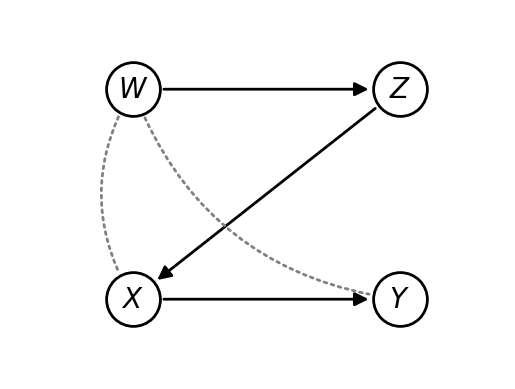

In [3]:
new_napkin.graph.draw()

## Line 3 of ID corresponds to Lemma 6
3. $\text{let }\mathbf W = (\mathbf V - X) - An(\mathbf Y)_{G_{\bar{\mathbf X}}}. \\ \text{if } \mathbf W \neq \emptyset, \text{ return } \mathbf{ID}\left(\mathbf y, \mathbf x\cup \mathbf w, P, G\right)$

 Forces an action on any node where such an action would have no effect on $\mathbf Y$—assuming we already acted on $\mathbf X$. Since actions remove incoming arrows, we can view line 3 as simplifying the causal graph we consider by removing certain arcs from the graph, without affecting the overall answer.

ID line 3 corresponds to Lemma 6


**Lemma 6.** Let $W = (V \setminus X) \setminus \text{An}(Y)_{G_{\overline{X}}}$. Then $P_x(y) = P_{x,w}(y)$, where $w$ are arbitrary values of $W$.

*Proof:* Note that by assumption, $(Y \perp\!\!\!\perp W \mid X)_{G_{\overline{X},\,\overline{W}}}$. The conclusion follows by rule 3. $\square$




Estimand: $P(W, X, Y, Z)$

P(W, X, Y, Z)

Query: $P[W,Z,X](Y)$

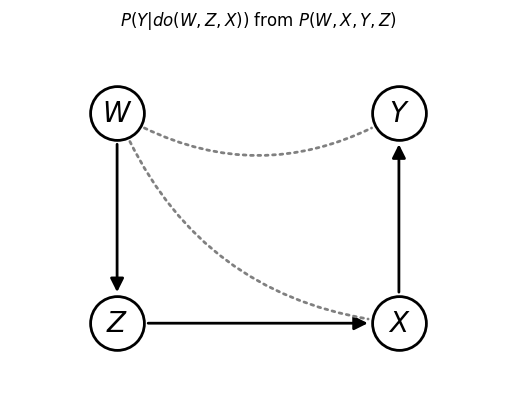

In [4]:
def print_identification(identification: Identification) -> None:
    """Print the graph."""
    display(Markdown(f"Estimand: ${identification.estimand}$"))
    display(identification.estimand)
    outcomes = identification.query.outcomes
    interventions = identification.query.treatments
    display(Markdown(f"Query: ${P[interventions](outcomes)}$"))
    identification.graph.draw(
        title=f"$P({outcomes} | do({interventions}))$ from ${identification.estimand}$"
    )


napkin_line_3_in = Identification.from_expression(
    query=P(Y @ X),
    graph=new_napkin.graph,
)

napkin_line_3_out = line_3(napkin_line_3_in)
print_identification(napkin_line_3_out)

Asking if $W$ and $Z$ are non-ancestors of $Y$ after removing incoming edges from $X$ is equivalent to asking if

$$(Y \perp\!\!\!\perp W, Z \mid X)_{G_{\overline{X},\,\overline{W}, \overline{Z}}}$$


By rule 3 of the do calculus, $P_{do(x)}(y) = P_{do(x,w,z)}(y)$ because $(Y \perp\!\!\!\perp W, Z \mid X)_{G_{\overline{X},\,\overline{W}, \overline{Z}}}$

## Line 7 of ID corresponds to Lemma 8

7. &nbsp; &nbsp;&nbsp;$\text{ if }(\exists S')S\subset S'\in C(G) \\ \text{ return }\mathbf{ID}\left(\mathbf y, \mathbf x\cap S', \prod_{\{i|V_i\in S'\}}P(V_i|V_\pi^{(i-1)}\cap S', V_\pi^{(i-1)} - S'), G_{S'}\right)$.

The most complex case where $\mathbf X$ is partitioned into two sets, $\mathbf W$ which contain bidirected arcs into other nodes in the subproblem, and $\mathbf Z$ which do not. In this situation, identifying $P(\mathbf y|do(\mathbf x))$ from $P(v)$ is equivalent to identifying $P(\mathbf y|do(\mathbf w))$ from $P(\mathbf V|do(\mathbf z))$, since $P(\mathbf y|do(\mathbf x)) = P(\mathbf y|do(\mathbf w), do(\mathbf z))$. But the term $P(\mathbf V|do(\mathbf z))$ is identifiable using the previous base case, so we can consider the subproblem of identifying $P(\mathbf y|do(\mathbf w))$.



ID line 7 corresponds to Lemma 8


**Lemma 8.** Whenever the conditions of the last recursive call of ID are satisfied, $P_x$ obtained from $P$ in the graph $G$ is equal to $P_{x \cap S'}$ obtained from

$$P' = \prod_{V_i \in S'} P\!\left(V_i \;\middle|\; V_\pi^{(i-1)} \cap S',\; v_\pi^{(i-1)} \setminus S'\right)$$

in the graph $S'$.

*Proof:* It is easy to see that when the last recursive call executes, $X$ and $S'$ partition $G$, and $X \subseteq \text{An}(S')_G$. This implies that the submodel $M_{x \setminus s'}$ induces the graph $G \setminus (X \setminus S') = S'$. The distribution $P_{x \setminus s'}$ of $M_{x \setminus s'}$ is equal to $P'$ by the proof of Lemma 4. It now follows that $P_x = P_{x \cap s',\, x \setminus s'} = P_{x \cap s'}$. $\square$



Estimand: $P(W) * P(X | W, Z) * P(Y | W, X, Z)$

P(W) * P(X | W, Z) * P(Y | W, X, Z)

Query: $P[W,X](Y)$

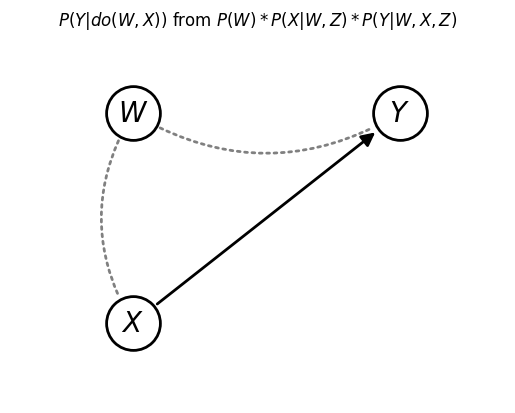

In [5]:
napkin_line_7_out = line_7(napkin_line_3_out)
print_identification(napkin_line_7_out)

The  C-component of $G\backslash \{X, W, Z\}$ is $S=\{Y\}$.  The set of C-components of $G$ are $S'_1=\{X,W,Y\}$ and $S'_2=\{Z\}$.  
Since $S\subset S'_1$, by Lemma 8, $P_{do(x,w,z)}$ obtained from $P$ in $G$ is equal to $P_{do(x,w)}$ obtained from $P'=P(W)P(X\mid W,Z)P(Y\mid W, X,Z)$ in $G\backslash \{Z\} = S'_1$ 




## Line 2 of ID corresponds to Lemma 5

2. $\text{if }\mathbf V - An(\mathbf Y)_G \neq \emptyset \\  \text{ return } \mathbf{ ID}\left(\mathbf y, \mathbf x\cap An(\mathbf Y)_G, \sum_{\mathbf V - An(Y)_G}P, G_{An(\mathbf Y)}\right)$

 If we are interested in the effect on $\mathbf Y$, it is sufficient to restrict our attention on the parts of the model ancestral to $\mathbf Y$.
 



Line 2 of ID corresponds to Lemma 5

**Lemma 5.** Let $X' = X \cap \text{An}(Y)_G$. Then $P_x(y)$ obtained from $P$ in $G$ is equal to $P_{x'}(y)$ obtained from $P' = P(\text{An}(Y))$ in $\text{An}(Y)_G$.

*Proof:* Let $W = V \setminus \text{An}(Y)_G$. Then the submodel $M_w$ induces the graph $G \setminus W = \text{An}(Y)_G$, and its distribution is $P' = P_w(\text{An}(Y)) = P(\text{An}(Y))$ by rule 3. Now $P_x(y) = P_{x,w}(y) = P_{x',w}(y) = P_{x'}(y)$ by rule 3. $\square$



Estimand: $Sum[W](P(W) * P(X | W, Z) * P(Y | W, X, Z))$

Sum[W](P(W) * P(X | W, Z) * P(Y | W, X, Z))

Query: $P[X](Y)$

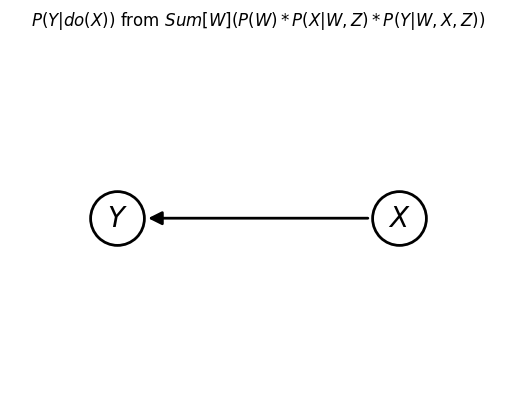

In [6]:
napkin_line_2_out = line_2(napkin_line_7_out)
print_identification(napkin_line_2_out)

By lemma 5, $P_{do(x,w)}(Y) obtained from  $P$  in $G_{S_1'}$ is equal to $P_{do(x)}(Y) obtained from P' in $An(Y)_G$.

## Line 6 of ID corresponds to Lemma 7

6. &nbsp; &nbsp;&nbsp;$\text{ if }S\in C(G) \\ \text{ return }\sum_{S - \mathbf y}\prod_{\{i|V_i\in S\}}P\left(v_i|v_\pi^{(i-1)}\right)$

Asserts that if there are no bidirected arcs from X to the other nodes in the current subproblem under consideration, then we can replace acting on X by conditioning, and thus solve the subproblem.  $V_\pi^{(i-1)}$ is the set of nodes preceding $V_i$ in some topological ordering $\pi$ in $G$.



Line 6 of ID corresponds to Lemma 7

**Lemma 7.** When the conditions of line 6 are satisfied,

$$P_x(y) = \sum_{s \setminus y}\;\prod_{V_i \in S} P(v_i \mid v_\pi^{(i-1)}).$$

*Proof:* If line 6 preconditions are met, then $G$ local to that recursive call is partitioned into $S$ and $X$, and there are no bidirected arcs from $X$ to $S$. The conclusion now follows from the proof of Lemma 4. $\square$


In [7]:
line_6_out = line_6(napkin_line_2_out)
line_6_out

P(Y | X)

The C-component of $G\backslash \{x\} = \{y\}$ is also a C-component of $G$, so $P_{do(x)}(y) = \sum_{s \setminus y}\;\prod_{V_i \in S} P(v_i \mid v_\pi^{(i-1)}) = P(y|x)$